In [2]:
import pandas as pd
import numpy as np

# imbalance methods tool
from imblearn.under_sampling import TomekLinks

# top 3 
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from lightgbm                  import LGBMClassifier

#  Hyperparameter Tuning & Evalauation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics         import accuracy_score, f1_score, precision_score, recall_score, classification_report

import warnings
warnings.filterwarnings('ignore') 

In [3]:
# Loads Cleanded 
X_train = pd.read_csv('../data/cleaned/X_train_clean.csv')
X_test  = pd.read_csv('../data/cleaned/X_test_clean.csv')

# 2. Loads Target (y) with convert to (Series)
y_train = pd.read_csv('../data/cleaned/y_train_clean.csv').squeeze()
y_test  = pd.read_csv('../data/cleaned/y_test_clean.csv').squeeze()

# 3. rm 
X_train.columns = X_train.columns.str.replace(r'[\[\]\{\}\:\,"]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]\{\}\:\,"]', '_', regex=True)

print(f"Loads Successfully !: X_train {X_train.shape} | X_test {X_test.shape}")


Loads Successfully !: X_train (13979, 262) | X_test (3495, 262)


In [4]:
print("⏳ กำลังเริ่มกระบวนการสุ่มคัดกรอง Tomek Links บนข้อมูล Train...")

tl = TomekLinks(n_jobs=-1)
X_train_res, y_train_res = tl.fit_resample(X_train, y_train)

print(f"✅ ทำ Tomek Links สำเร็จ: ข้อมูล Train ปรับลดจาก {X_train.shape[0]} แถว เหลือ {X_train_res.shape[0]} แถว")


⏳ กำลังเริ่มกระบวนการสุ่มคัดกรอง Tomek Links บนข้อมูล Train...
✅ ทำ Tomek Links สำเร็จ: ข้อมูล Train ปรับลดจาก 13979 แถว เหลือ 13525 แถว


In [17]:
# 1. กำหนดช่วงพารามิเตอร์ในการสุ่มค้นหา (Tuning Parameter Spaces) - เวอร์ชันเขียนแยกบรรทัดปลอดภัย
param_grids = {
    "XGBoost": {
        "model": XGBClassifier(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [
                100, 
                200, 
                300, 
                500
            ],
            'max_depth': [
                3, 
                5, 
                7, 
                9
            ],
            'learning_rate': [
                0.01, 
                0.05, 
                0.1, 
                0.2
            ],
            'subsample': [
                0.6, 
                0.8, 
                1.0
            ],
            'colsample_bytree': [
                0.6, 
                0.8, 
                1.0
            ]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            'n_estimators': [
                100, 
                200, 
                300, 
                500
            ],
            'max_depth': [
                -1, 
                3, 
                5, 
                7, 
                9
            ],
            'learning_rate': [
                0.01, 
                0.05, 0.1, 
                0.2
            ],
            'num_leaves': [
                15, 
                31, 
                63, 
                127
            ],
            'subsample': [
                0.6, 
                0.8, 
                1.0
            ]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [
                100, 
                200, 
                300, 
                500
            ],
            'max_depth': [
                None, 
                10, 
                20, 
                30
            ],
            'min_samples_split': [
                2, 
                5, 
                10
            ],
            'min_samples_leaf': [
                1, 
                2, 
                4
            ],
            'max_features': [
                'sqrt', 
                'log2', 
                None
            ]
        }
    }
}

tuning_results = []

# 2. เริ่มลูปกระบวนการ Tuning ทีละตัวแปรจำลอง
for name, config in param_grids.items():
    print(f"🔄 กำลังเริ่มจูนโมเดล: {name} (ขั้นตอนนี้อาจใช้เวลาสักครู่)...")
    
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=15,          # สุ่มทดสอบ 15 รูปแบบต่อโมเดลเพื่อความรวดเร็ว
        scoring='f1_macro', # เลือกคู่ที่ให้ F1-Macro สูงสุดในการทำ CV
        cv=3,               # ทำ 3-Fold Cross Validation บนข้อมูล Train
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train_res, y_train_res)
    
    # ดึงโมเดลที่ดีที่สุดหลังจูน (Best Estimator) มาทดสอบกับข้อสอบจริง (Test Set)
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # บันทึกประวัติและผลลัพธ์
    tuning_results.append({
        "Model"          : f"{name} (Tuned)",
        "Best Params"    : search.best_params_,
        "CV F1-Mac"      : search.best_score_,
        "Test Accuracy"  : accuracy_score(y_test, y_pred),
        "Test F1-Mac"    : f1_score(y_test, y_pred, average="macro"),
        "Test F1-Wtd"    : f1_score(y_test, y_pred, average="weighted"),
        "Test Precision" : precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Test Recall"    : recall_score(y_test, y_pred, average="macro", zero_division=0)
    })

# 3. จัดทำตารางเปรียบเทียบผลลัพธ์เพื่อนำไปรายงานผล
tuning_df = pd.DataFrame(tuning_results).set_index("Model")
metric_cols = ["CV F1-Mac", "Test Accuracy", "Test F1-Mac", "Test F1-Wtd", "Test Precision", "Test Recall"]
tuning_df_display = tuning_df[metric_cols].sort_values("Test F1-Mac", ascending=False).round(4)

print("\n📊 ตารางเปรียบเทียบผลลัพธ์หลังเสร็จสิ้นกระบวนการ Hyperparameter Tuning:")
tuning_df_display


🔄 กำลังเริ่มจูนโมเดล: XGBoost (ขั้นตอนนี้อาจใช้เวลาสักครู่)...


/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API.

🔄 กำลังเริ่มจูนโมเดล: LightGBM (ขั้นตอนนี้อาจใช้เวลาสักครู่)...
🔄 กำลังเริ่มจูนโมเดล: Random Forest (ขั้นตอนนี้อาจใช้เวลาสักครู่)...

📊 ตารางเปรียบเทียบผลลัพธ์หลังเสร็จสิ้นกระบวนการ Hyperparameter Tuning:


,CV F1-Mac,Test Accuracy,Test F1-Mac,Test F1-Wtd,Test Precision,Test Recall
Model,,,,,,
XGBoost (Tuned),0.8238,0.9087,0.8179,0.9023,0.8515,0.7964
LightGBM (Tuned),0.8183,0.9050,0.8110,0.8984,0.8434,0.7902
Random Forest (Tuned),0.8250,0.8924,0.7947,0.8879,0.8150,0.7799


In [19]:
LABEL_MAP = {
    0: "Drought",
    1: "Earthquake",
    2: "Epidemic",
    3: "Extreme Temp",
    4: "Flood",
    5: "Landslide",
    6: "Storm",
    7: "Wildfire",
}
TARGET_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

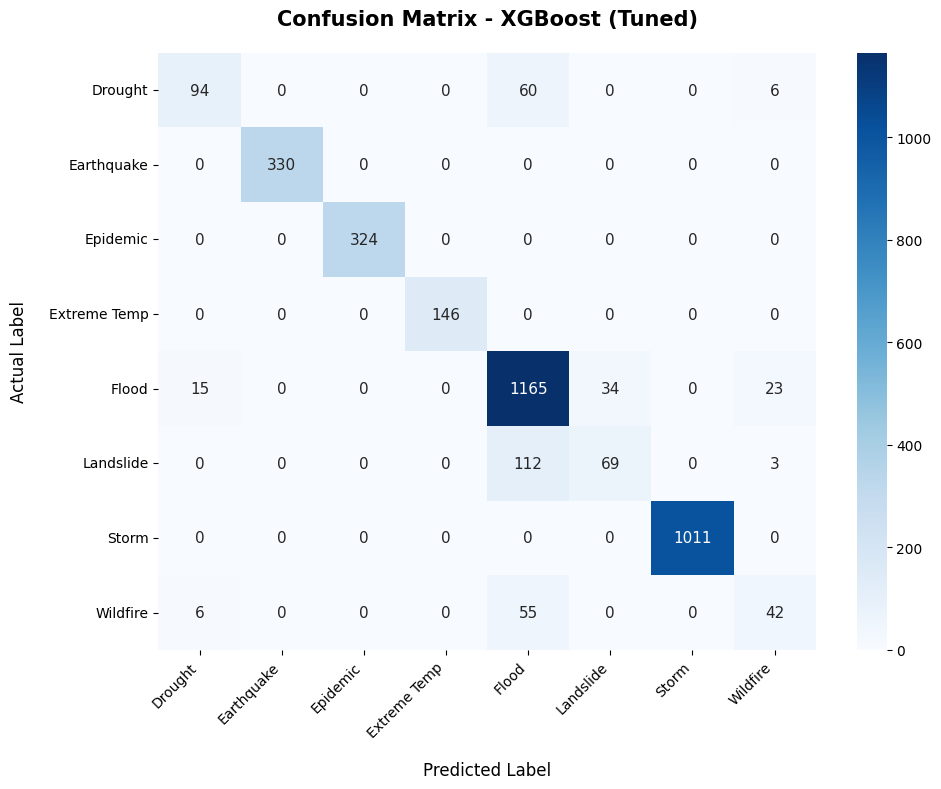

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

# 1. กำหนดโครงสร้างคลาสตามชื่อภัยพิบัติที่คุณระบุ
LABEL_MAP = {
    0: "Drought",
    1: "Earthquake",
    2: "Epidemic",
    3: "Extreme Temp",
    4: "Flood",
    5: "Landslide",
    6: "Storm",
    7: "Wildfire",
}
TARGET_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

# 2. จำลองการฟิตโมเดล XGBoost (Tuned) แชมป์อันดับ 1
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res)
y_pred_final = final_model.predict(X_test)

# 3. คำนวณค่า Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

# 4. ตั้งค่าพื้นที่กราฟและขนาดให้กว้างขึ้นเล็กน้อยเพื่อรองรับชื่อตัวอักษร
plt.figure(figsize=(10, 8))

# 5. ใช้ Seaborn Heatmap ในการวาดตารางและส่งค่า TARGET_NAMES เข้าแกน X และ Y
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=TARGET_NAMES, # 👈 แสดงชื่อภัยพิบัติบนแกนพยากรณ์ (แนวนอน)
    yticklabels=TARGET_NAMES, # 👈 แสดงชื่อภัยพิบัติบนแกนข้อมูลจริง (แนวตั้ง)
    cbar=True,
    annot_kws={"size": 11}
)

# 6. ตั้งชื่อหัวข้อและคำอธิบายแกน
plt.title('Confusion Matrix - XGBoost (Tuned)', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, labelpad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=15)

# หมุนตัวอักษรแกน X เล็กน้อยเพื่อไม่ให้ชื่อยาว ๆ ทับซ้อนกัน
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


📊 คะแนน Test F1-Macro หลังปรับ Class Weight: 0.8061 (ของเดิมก่อนปรับ = 0.8179)


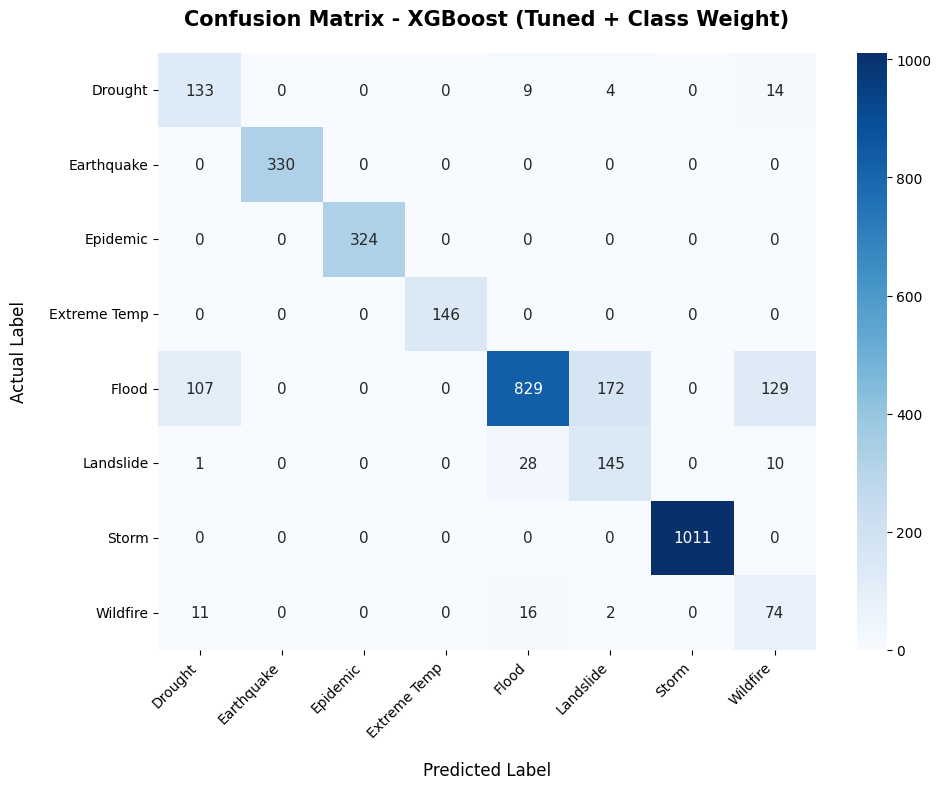

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics         import confusion_matrix, f1_score
from xgboost                 import XGBClassifier

# 1. คำนวณน้ำหนักให้แต่ละแถวตามสัดส่วนคลาสจริง (คลาสน้อยจะได้น้ำหนักเยอะขึ้นโดยอัตโนมัติ)
# วิธีนี้เรียกว่า 'balanced' weight tuning
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)

# 2. ตั้งค่าโมเดล XGBoost (Tuned) ตัวแชมป์ของคุณ
weighted_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 3. สั่งเทรนโดยส่ง sample_weight เข้าไปด้วย 👈 ตรงนี้คือหัวใจสำคัญของข้อสอง
weighted_xgb.fit(X_train_res, y_train_res, sample_weight=sample_weights)

# 4. พยากรณ์ผลลัพธ์
y_pred_weighted = weighted_xgb.predict(X_test)

# 5. ปริ้นต์เช็กคะแนน F1 Macro ใหม่เทียบของเดิม
new_f1 = f1_score(y_test, y_pred_weighted, average="macro")
print(f"📊 คะแนน Test F1-Macro หลังปรับ Class Weight: {new_f1:.4f} (ของเดิมก่อนปรับ = 0.8179)")

# 6. พล็อต Confusion Matrix เพื่อดูความเปลี่ยนแปลง
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_weighted, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=TARGET_NAMES, 
    yticklabels=TARGET_NAMES, 
    cbar=True,
    annot_kws={"size": 11}
)

plt.title('Confusion Matrix - XGBoost (Tuned + Class Weight)', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, labelpad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
